In [1]:
import json
import yfinance as yf
import requests
from bs4 import BeautifulSoup
import pandas as pd

In [2]:
with open('company_tickers.json', 'r') as f:
    data = json.load(f)

In [3]:
tickers = []
for x in data.items():
    tickers.append(x[1]['ticker'])
ticker_test = tickers[0:5]

In [4]:
import time
def fetch_stock_data(tickers):
    #all_data = {}
    infor = {}
    print('Downloading yfinance historical price data 2010/01/01 to 2025/03/16')
    for ticker in tickers:
        try:
            #all_data[ticker] = yf.download(ticker, start="2010-01-01", end="2025-03-16", progress = False, interval='1wk')
            #time.sleep(2.001)
            infor[ticker] = yf.Ticker(ticker)
            time.sleep(2.001)  # Sleep for 2 seconds between requests to avoid being blocked
        except Exception as e:
            print(f"Error downloading {ticker}: {e}")
            time.sleep(2.001)
    return infor

In [5]:
def get_sp500_tickers():
    """Fetch the list of S&P 500 tickers from Wikipedia."""
    url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
    response = requests.get(url)
    soup = BeautifulSoup(response.text, 'html.parser')
    table = soup.find('table', {'id': 'constituents'})
    tickers = []
    for row in table.findAll('tr')[1:]:
        ticker = row.findAll('td')[0].text.strip()
        tickers.append(ticker)
    return tickers

sp500_tickers = get_sp500_tickers()

In [6]:
#Need to figure out what i want from each section so I can save as a csv.
#I can save the price data as a csv or could go without the price data and just do yf.Ticker
#Remove stocks that are too large or remove ones where the mktcap is too small
#Remove pharma companies
sp500_infor = fetch_stock_data(sp500_tickers)

In [7]:
def get_info_df(tickers, infor):
    dict_list = []
    for x in tickers:
        info = infor[x].info
        dict_list.append(info)
    df = pd.DataFrame(dict_list)
    return df

In [8]:
sp500_df = get_info_df(sp500_tickers, sp500_infor)
sp500_df.to_csv('sp500_info.csv')


In [9]:
df_2000 = pd.read_excel('russell_2000.xlsx')
russell2000_info = fetch_stock_data(df_2000['Ticker'])
#r2000_df = get_info_df( df_2000['Ticker'], russell2000_info)
#r2000_df.to_csv('r2000_info.csv')
#r2000_df.head(2)

In [10]:
dict_list = {}
for x in df_2000['Ticker']:
    try:
        info = russell2000_info[x].info
        dict_list[x] = info
        
    except Exception as e:
        print(f"Error downloading {x}: {e}")


Error downloading ACCD: list index out of range
Error downloading AMPS: list index out of range
Error downloading ATSG: list index out of range
Error downloading AVTE: list index out of range
Error downloading BECN: list index out of range
Error downloading DTC: list index out of range
Error downloading ENFN: list index out of range
Error downloading FFNW: list index out of range
Error downloading FNA: list index out of range


404 Client Error: Not Found for url: https://query2.finance.yahoo.com/v10/finance/quoteSummary/GEFB?modules=financialData%2CquoteType%2CdefaultKeyStatistics%2CassetProfile%2CsummaryDetail&corsDomain=finance.yahoo.com&formatted=false&symbol=GEFB&crumb=9GQ0fOEKOgh


Error downloading GEFB: 'NoneType' object has no attribute 'update'
Error downloading GTXI: list index out of range
Error downloading LGTY: list index out of range
Error downloading METCV: list index out of range
Error downloading ML: list index out of range


404 Client Error: Not Found for url: https://query2.finance.yahoo.com/v10/finance/quoteSummary/MSFUT?modules=financialData%2CquoteType%2CdefaultKeyStatistics%2CassetProfile%2CsummaryDetail&corsDomain=finance.yahoo.com&formatted=false&symbol=MSFUT&crumb=9GQ0fOEKOgh


Error downloading MSFUT: 'NoneType' object has no attribute 'update'
Error downloading PDCO: list index out of range
Error downloading SBT: list index out of range
Error downloading SWI: list index out of range
Error downloading VCSA: list index out of range


In [11]:

russell_df = pd.DataFrame(dict_list).T

In [12]:
russell_df.to_csv('r2000_info.csv')

In [13]:
r2000_df = pd.read_csv('r2000_info.csv')
r2000_df.head(1)

,Unnamed: 0,address1,address2,city,state,zip,country,phone,website,industry,...,beta3Year,fundFamily,fundInceptionDate,legalType,threeYearAverageReturn,fiveYearAverageReturn,trailingThreeMonthReturns,trailingThreeMonthNavReturns,netAssets,netExpenseRatio
0,AAMI,200 Clarendon Street,53rd Floor,Boston,MA,02116,United States,617-369-7300,https://www.bsig.com,Asset Management,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
df_cleaned = r2000_df.dropna(axis=1, thresh=1500)
df_cleaned.head()

,Unnamed: 0,address1,city,state,zip,country,phone,website,industry,industryKey,...,averageDailyVolume3Month,fiftyTwoWeekLowChange,fiftyTwoWeekLowChangePercent,fiftyTwoWeekRange,fiftyTwoWeekHighChange,fiftyTwoWeekHighChangePercent,fiftyTwoWeekChangePercent,displayName,forwardEps,epsForward
0,AAMI,200 Clarendon Street,Boston,MA,02116,United States,617-369-7300,https://www.bsig.com,Asset Management,asset-management,...,259123.0,8.980000,0.418648,21.45 - 31.52,-1.090000,-0.034581,33.508778,Acadian Asset Management,NaN,NaN
1,AAOI,13139 Jess Pirtle Boulevard,Sugar Land,TX,77478,United States,281 295 1800,https://www.ao-inc.com,Communication Equipment,communication-equipment,...,4644946.0,12.410001,1.852239,6.7 - 44.5,-25.390000,-0.570562,84.287010,Applied Optoelectronics,0.73,0.73
2,AAT,3420 Carmel Mountain Road,San Diego,CA,92121-1069,United States,858 350 2600,https://www.americanassetstrust.com,REIT - Diversified,reit-diversified,...,442233.0,2.699999,0.161773,16.69 - 29.15,-9.760000,-0.334820,-13.793105,American Assets Trust,0.72,0.72
3,ABCB,3490 Piedmont Road NE,Atlanta,GA,30305,United States,404 639 6500,https://www.amerisbank.com,Banks - Regional,banks-regional,...,486325.0,17.460000,0.380475,45.89 - 74.56,-11.209999,-0.150349,26.653385,NaN,5.03,5.03
4,ABG,"2905 Premiere Parkway, NW",Duluth,GA,30097,United States,770 418 8200,https://www.asburyauto.com,Auto & Truck Dealerships,auto-truck-dealerships,...,236683.0,35.195007,0.174509,201.68 - 312.56,-75.685000,-0.242146,0.037539,Asbury Automotive,27.69,27.69


In [15]:
#df_cleaned.columns.to_list()

In [16]:
dropcols = ['Unnamed: 0','address1', 'phone', 'website', 'longBusinessSummary', 'companyOfficers', 'auditRisk', 'boardRisk', 'compensationRisk', 'governanceEpochDate', 'executiveTeam',
 'maxAge', 'priceHint', 'previousClose', 'open', 'dayLow', 'dayHigh', 'regularMarketPreviousClose', 'regularMarketOpen', 'regularMarketDayLow',
 'regularMarketDayHigh', 'payoutRatio', 'averageVolume10days', 'averageDailyVolume10Day', 'bid', 'ask', 'bidSize', 'askSize', 'fiftyTwoWeekLow',
 'fiftyTwoWeekHigh', 'priceToSalesTrailing12Months', 'fiftyDayAverage', 'twoHundredDayAverage', 'trailingAnnualDividendYield',
 'currency', 'tradeable', 'enterpriseValue', 'forwardPE', 'floatShares', 'sharesShort', 'sharesShortPriorMonth', 'sharesShortPreviousMonthDate',
 'dateShortInterest', 'sharesPercentSharesOut', 'shortRatio', 'shortPercentOfFloat', 'impliedSharesOutstanding', 'priceToBook', 'lastFiscalYearEnd',
 'nextFiscalYearEnd', 'mostRecentQuarter', 'netIncomeToCommon', 'trailingEps', 'enterpriseToRevenue', 'enterpriseToEbitda', '52WeekChange', 'SandP52WeekChange',
 'quoteType', 'targetHighPrice', 'targetLowPrice', 'targetMeanPrice', 'targetMedianPrice', 'recommendationKey', 'numberOfAnalystOpinions', 'revenueGrowth',
 'grossMargins', 'ebitdaMargins', 'operatingMargins', 'financialCurrency', 'language', 'region', 'typeDisp', 'quoteSourceName', 'triggerable', 'customPriceAlertConfidence',
 'marketState', 'shortName', 'longName', 'earningsTimestampEnd', 'earningsCallTimestampStart', 'earningsCallTimestampEnd', 'isEarningsDateEstimate',
 'epsTrailingTwelveMonths', 'epsCurrentYear', 'priceEpsCurrentYear', 'fiftyDayAverageChange', 'fiftyDayAverageChangePercent', 'twoHundredDayAverageChange',
 'twoHundredDayAverageChangePercent', 'sourceInterval', 'exchangeDataDelayedBy', 'cryptoTradeable', 'hasPrePostMarketData', 'firstTradeDateMilliseconds',
 'regularMarketChange',
 'regularMarketDayRange',
 'fullExchangeName',
 'averageDailyVolume3Month',
 'earningsTimestamp',
 'earningsTimestampStart',
 'corporateActions',
 'regularMarketTime',
 'exchange',
 'messageBoardId',
 'exchangeTimezoneName',
 'exchangeTimezoneShortName',
 'gmtOffSetMilliseconds',
 'market',
 'esgPopulated',
 'regularMarketChangePercent',
 'compensationAsOfEpochDate',
 'epsForward',
 'industryKey',
 'industryDisp',
 'sectorKey',
 'sectorDisp']
df_small = df_cleaned.drop(dropcols, axis = 1)

In [17]:
df_small.head()

,city,state,zip,country,industry,sector,fullTimeEmployees,shareHolderRightsRisk,overallRisk,beta,...,symbol,regularMarketPrice,fiftyTwoWeekLowChange,fiftyTwoWeekLowChangePercent,fiftyTwoWeekRange,fiftyTwoWeekHighChange,fiftyTwoWeekHighChangePercent,fiftyTwoWeekChangePercent,displayName,forwardEps
0,Boston,MA,02116,United States,Asset Management,Financial Services,383.0,1.0,2.0,1.369,...,AAMI,30.430,8.980000,0.418648,21.45 - 31.52,-1.090000,-0.034581,33.508778,Acadian Asset Management,NaN
1,Sugar Land,TX,77478,United States,Communication Equipment,Technology,3309.0,8.0,7.0,2.545,...,AAOI,19.110,12.410001,1.852239,6.7 - 44.5,-25.390000,-0.570562,84.287010,Applied Optoelectronics,0.73
2,San Diego,CA,92121-1069,United States,REIT - Diversified,Real Estate,230.0,9.0,6.0,1.155,...,AAT,19.390,2.699999,0.161773,16.69 - 29.15,-9.760000,-0.334820,-13.793105,American Assets Trust,0.72
3,Atlanta,GA,30305,United States,Banks - Regional,Financial Services,2045.0,2.0,2.0,0.919,...,ABCB,63.350,17.460000,0.380475,45.89 - 74.56,-11.209999,-0.150349,26.653385,NaN,5.03
4,Duluth,GA,30097,United States,Auto & Truck Dealerships,Consumer Cyclical,15000.0,6.0,4.0,0.981,...,ABG,236.875,35.195007,0.174509,201.68 - 312.56,-75.685000,-0.242146,0.037539,Asbury Automotive,27.69


In [18]:
sp500_df = pd.read_csv('sp500_info.csv')
sp500_df.head(1)

,Unnamed: 0,address1,city,state,zip,country,phone,website,industry,industryKey,...,longName,marketState,trailingPegRatio,address2,displayName,fax,ipoExpectedDate,prevName,nameChangeDate,industrySymbol
0,0,3M Center,Saint Paul,MN,55144-1000,United States,651 733 1110,https://www.3m.com,Conglomerates,conglomerates,...,3M Company,REGULAR,3.5074,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
small_sp500 = sp500_df.drop(dropcols, axis = 1)#.dropna(axis=1, thresh=450)
small_sp500.head()

,city,state,zip,country,industry,sector,fullTimeEmployees,shareHolderRightsRisk,overallRisk,irWebsite,...,dividendDate,averageAnalystRating,trailingPegRatio,address2,displayName,fax,ipoExpectedDate,prevName,nameChangeDate,industrySymbol
0,Saint Paul,MN,55144-1000,United States,Conglomerates,Industrials,61500.0,4.0,4.0,http://phx.corporate-ir.net/phoenix.zhtml?c=80...,...,1.741738e+09,2.2 - Buy,3.5074,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Milwaukee,WI,53224,United States,Specialty Industrial Machinery,Industrials,12700.0,10.0,10.0,http://investor.shareholder.com/aosmith/,...,1.747267e+09,2.5 - Buy,1.8300,Suite 170,A. O. Smith,NaN,NaN,NaN,NaN,NaN
2,North Chicago,IL,60064-6400,United States,Medical Devices,Healthcare,114000.0,2.0,7.0,http://www.abbottinvestor.com/phoenix.zhtml?c=...,...,1.747267e+09,1.9 - Buy,NaN,Abbott Park,NaN,NaN,NaN,NaN,NaN,NaN
3,North Chicago,IL,60064-6400,United States,Drug Manufacturers - General,Healthcare,55000.0,9.0,7.0,NaN,...,1.747267e+09,1.9 - Buy,0.4019,NaN,AbbVie,NaN,NaN,NaN,NaN,NaN
4,Dublin,NaN,D02 P820,Ireland,Information Technology Services,Technology,801000.0,4.0,2.0,http://investor.accenture.com/phoenix.zhtml?c=...,...,1.747267e+09,1.8 - Buy,2.5204,Grand Canal Harbour,Accenture,353 1 646 2020,NaN,NaN,NaN,NaN


In [20]:
condition_sp500 = small_sp500[(small_sp500['beta'] > 1) & (small_sp500['freeCashflow'] >= 0) & (small_sp500['sector'] != 'Healthcare')]

In [21]:
import matplotlib.pyplot as plt

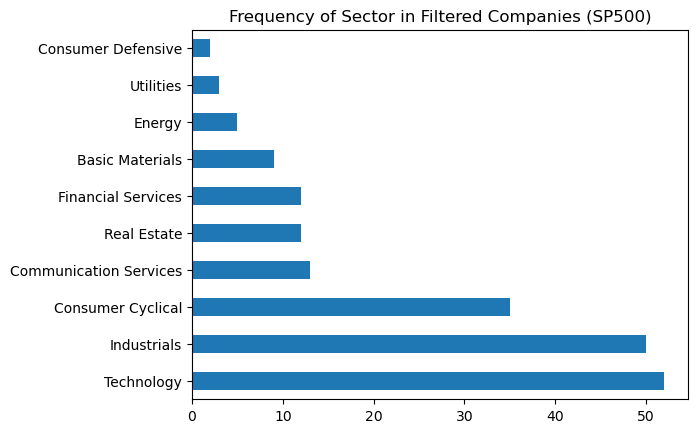

In [65]:
ax = condition_sp500['sector'].value_counts().plot(kind='barh')
ax.set_xlabel("") 
ax.set_ylabel("") 
ax.set_title('Frequency of Sector in Filtered Companies (SP500)')
plt.savefig('website/sector_counts_sp500.png', dpi=300, bbox_inches='tight')
plt.show()

In [66]:
condition_russ = df_small[(df_small['beta'] > 1) & (df_small['freeCashflow'] >= 0) & (df_small['sector'] != 'Healthcare')]

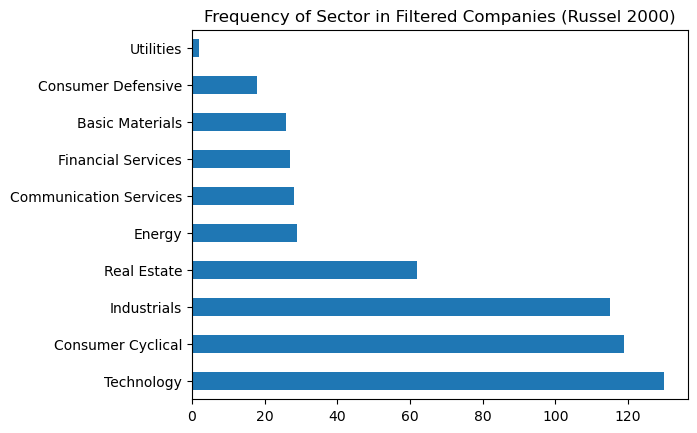

In [68]:
ax = condition_russ['sector'].value_counts().plot(kind='barh')
ax.set_xlabel("") 
ax.set_ylabel("") 
ax.set_title('Frequency of Sector in Filtered Companies (Russel 2000)')
plt.savefig('website/sector_counts_russel2000.png', dpi=300, bbox_inches='tight')
plt.show()

<Axes: >

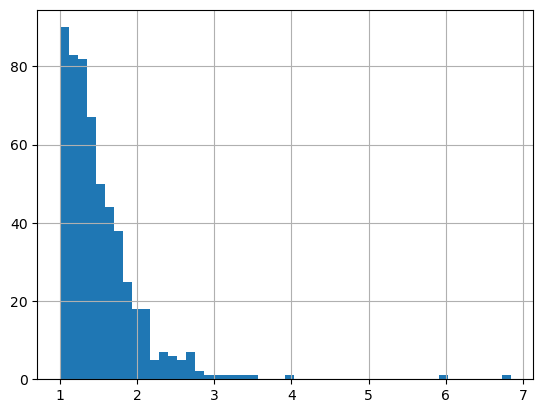

In [25]:
condition_russ['beta'].hist(bins=50)

In [26]:
condition_russ[condition_russ['beta'] > 4]

,city,state,zip,country,industry,sector,fullTimeEmployees,shareHolderRightsRisk,overallRisk,beta,...,symbol,regularMarketPrice,fiftyTwoWeekLowChange,fiftyTwoWeekLowChangePercent,fiftyTwoWeekRange,fiftyTwoWeekHighChange,fiftyTwoWeekHighChangePercent,fiftyTwoWeekChangePercent,displayName,forwardEps
1049,Fort Lauderdale,FL,33301,United States,Capital Markets,Financial Services,171.0,4.0,9.0,6.844,...,MARA,15.965,6.155,0.627421,9.81 - 30.28,-14.315001,-0.472754,-18.960398,MARA,0.04
1340,New York,NY,10017,United States,Software - Infrastructure,Technology,527.0,NaN,NaN,5.910,...,PGY,15.030,6.830,0.832927,8.2 - 19.2,-4.170001,-0.217188,22.824299,Pagaya,0.50


<Axes: >

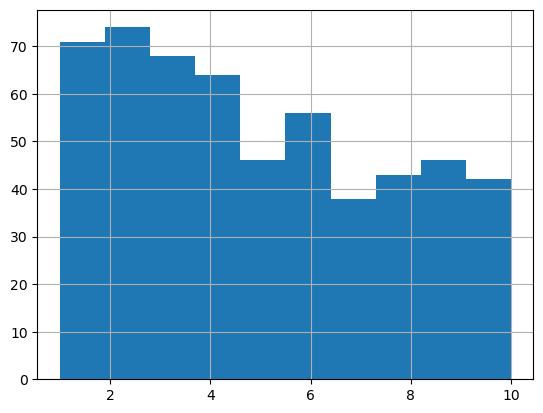

In [27]:
condition_russ['overallRisk'].hist(bins=10)

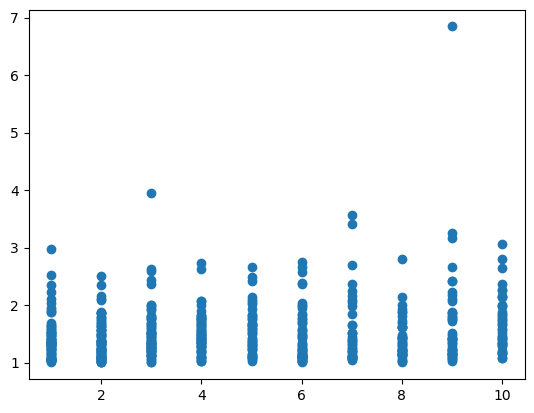

In [28]:
plt.scatter(data = condition_russ, x = 'overallRisk', y = 'beta')

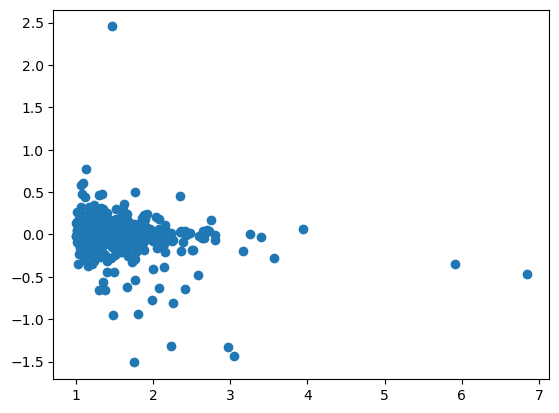

In [29]:
plt.scatter(data = condition_russ, x = 'beta', y = 'profitMargins')

In [30]:
condition_russ[condition_russ['profitMargins'] > 1]

,city,state,zip,country,industry,sector,fullTimeEmployees,shareHolderRightsRisk,overallRisk,beta,...,symbol,regularMarketPrice,fiftyTwoWeekLowChange,fiftyTwoWeekLowChangePercent,fiftyTwoWeekRange,fiftyTwoWeekHighChange,fiftyTwoWeekHighChangePercent,fiftyTwoWeekChangePercent,displayName,forwardEps
1569,Beachwood,OH,44122-7200,United States,REIT - Retail,Real Estate,172.0,2.0,3.0,1.467,...,SITC,12.115,1.66,0.158776,10.455 - 64.44,-52.325005,-0.811996,-78.133804,SITE Centers,-0.74


<Axes: >

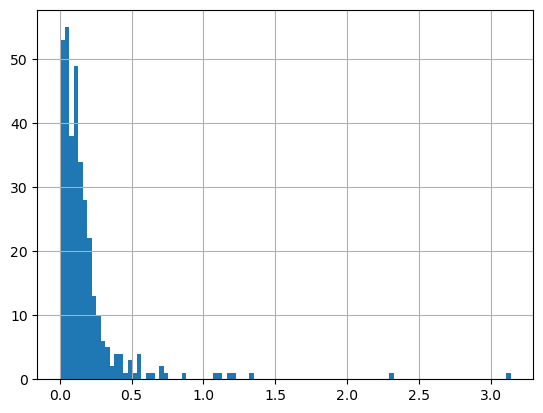

In [31]:
condition_russ[condition_russ['returnOnEquity'] > 0]['returnOnEquity'].hist(bins=100)

In [32]:
condition_russ[condition_russ['returnOnEquity'] > 20]

,city,state,zip,country,industry,sector,fullTimeEmployees,shareHolderRightsRisk,overallRisk,beta,...,symbol,regularMarketPrice,fiftyTwoWeekLowChange,fiftyTwoWeekLowChangePercent,fiftyTwoWeekRange,fiftyTwoWeekHighChange,fiftyTwoWeekHighChangePercent,fiftyTwoWeekChangePercent,displayName,forwardEps


<Axes: >

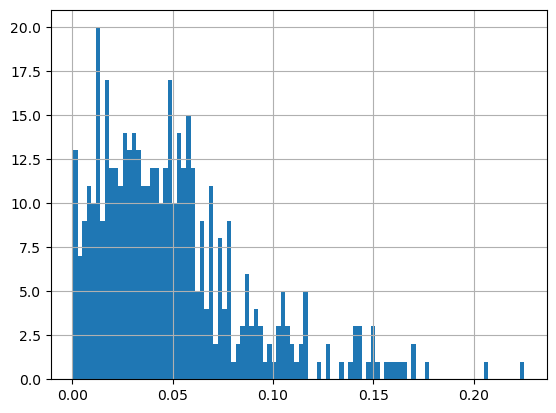

In [33]:
condition_russ[condition_russ['returnOnAssets'] > 0]['returnOnAssets'].hist(bins=100)

<Axes: xlabel='sector'>

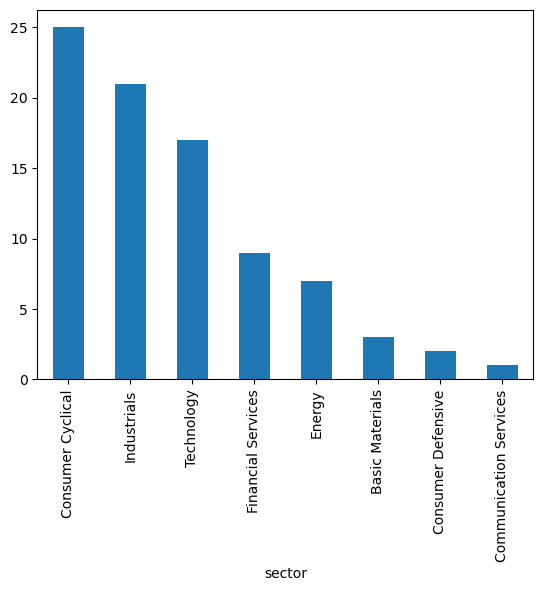

In [34]:
condition_russ[condition_russ['returnOnAssets'] > 0.075]['sector'].value_counts().plot(kind='bar')

<Axes: >

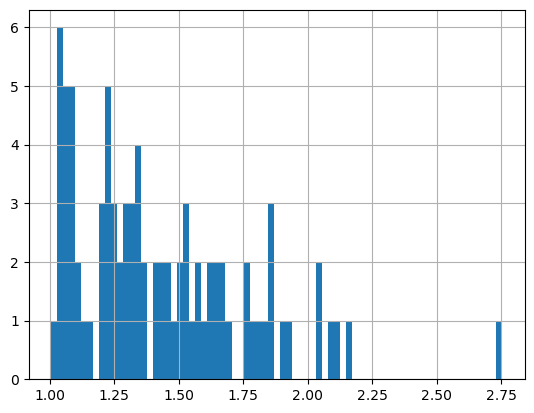

In [35]:
condition_russ[condition_russ['returnOnAssets'] > 0.075]['beta'].hist(bins=75)

<Axes: >

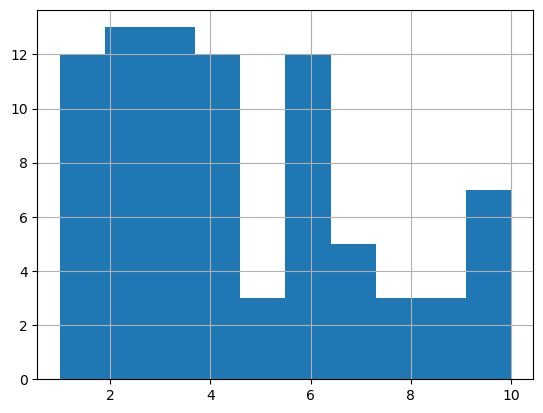

In [36]:
condition_russ[condition_russ['returnOnAssets'] > 0.075]['overallRisk'].hist(bins=10)

<Axes: >

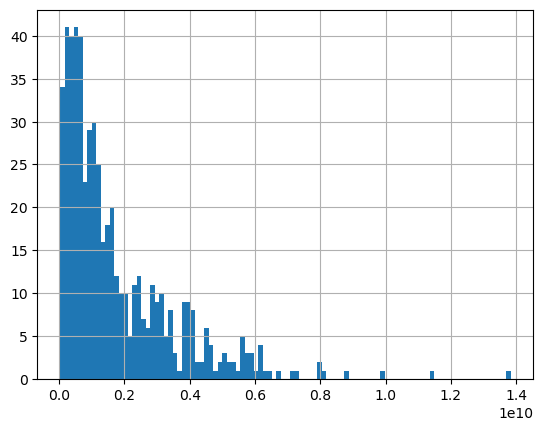

In [37]:
condition_russ['marketCap'].hist(bins = 100)

<Axes: >

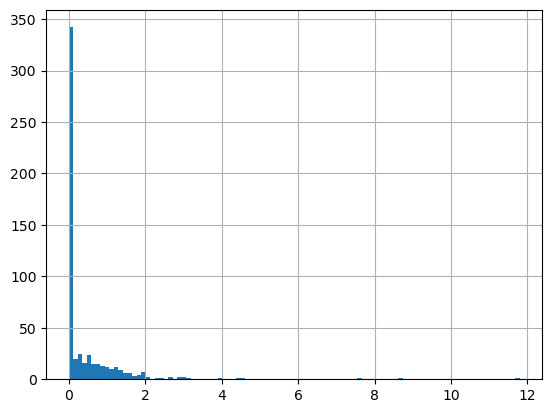

In [38]:
condition_russ['trailingAnnualDividendRate'].hist(bins = 100)

In [70]:
condition_sp500['revPerEmp'] = condition_sp500['totalRevenue']/condition_sp500['fullTimeEmployees']
condition_russ['revPerEmp'] = condition_russ['totalRevenue']/condition_russ['fullTimeEmployees']

C:\Users\owenh\AppData\Local\Temp\ipykernel_28824\1898315872.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  condition_sp500['revPerEmp'] = condition_sp500['totalRevenue']/condition_sp500['fullTimeEmployees']
C:\Users\owenh\AppData\Local\Temp\ipykernel_28824\1898315872.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  condition_russ['revPerEmp'] = condition_russ['totalRevenue']/condition_russ['fullTimeEmployees']


<Axes: >

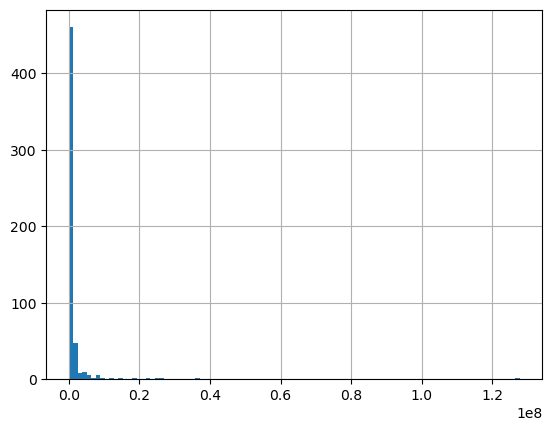

In [71]:
condition_russ['revPerEmp'].hist(bins = 100)

<Axes: >

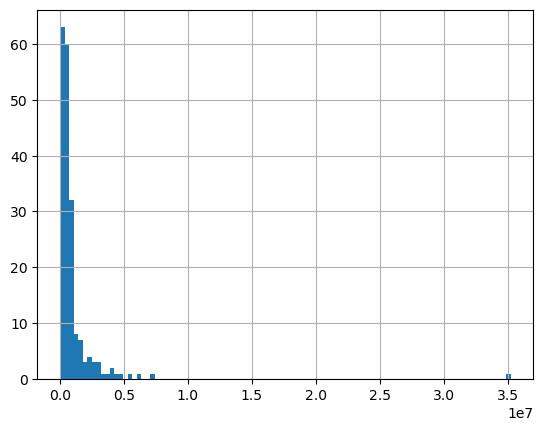

In [72]:
condition_sp500['revPerEmp'].hist(bins = 100)

In [84]:
russ_q3 = condition_russ['revPerEmp'].quantile(0.75)

# Filter rows where 'Score' is in the top quartile
top_quartile_russ = condition_russ[condition_russ['revPerEmp'] >= russ_q3]
top_quartile_russ = top_quartile_russ[(top_quartile_russ['bookValue'] > 0) & (top_quartile_russ['profitMargins'] > 0)]
top_quartile_russ.head()

,city,state,zip,country,industry,sector,fullTimeEmployees,shareHolderRightsRisk,overallRisk,beta,...,regularMarketPrice,fiftyTwoWeekLowChange,fiftyTwoWeekLowChangePercent,fiftyTwoWeekRange,fiftyTwoWeekHighChange,fiftyTwoWeekHighChangePercent,fiftyTwoWeekChangePercent,displayName,forwardEps,revPerEmp
0,Boston,MA,02116,United States,Asset Management,Financial Services,383.0,1.0,2.0,1.369,...,30.430,8.980000,0.418648,21.45 - 31.52,-1.090000,-0.034581,33.508778,Acadian Asset Management,NaN,1.357180e+06
2,San Diego,CA,92121-1069,United States,REIT - Diversified,Real Estate,230.0,9.0,6.0,1.155,...,19.390,2.699999,0.161773,16.69 - 29.15,-9.760000,-0.334820,-13.793105,American Assets Trust,0.72,1.962091e+06
14,Burr Ridge,IL,60527,United States,Gambling,Consumer Cyclical,1500.0,6.0,6.0,1.226,...,11.705,2.690000,0.298392,9.015 - 12.96,-1.255000,-0.096836,20.345879,Accel Entertainment,0.86,8.353780e+05
29,San Jose,CA,95134,United States,Software - Application,Technology,150.0,4.0,2.0,1.164,...,13.925,4.244900,0.438518,9.6801 - 17.46,-3.534999,-0.202463,20.757973,Adeia,1.36,2.535260e+06
54,Virginia Beach,VA,23462-3039,United States,REIT - Diversified,Real Estate,148.0,3.0,3.0,1.119,...,7.215,1.115000,0.182787,6.1 - 12.46,-5.245000,-0.420947,-38.290596,Armada Hoffler Properties,0.25,4.242993e+06


In [83]:
sp500_q3 = condition_sp500['revPerEmp'].quantile(0.75)

# Filter rows where 'Score' is in the top quartile
top_quartile_sp500 = condition_sp500[condition_sp500['revPerEmp'] >= sp500_q3]
top_quartile_sp500 = top_quartile_sp500[(top_quartile_sp500['bookValue'] > 0) & (top_quartile_sp500['profitMargins'] > 0)]
top_quartile_sp500.head()

,city,state,zip,country,industry,sector,fullTimeEmployees,shareHolderRightsRisk,overallRisk,irWebsite,...,averageAnalystRating,trailingPegRatio,address2,displayName,fax,ipoExpectedDate,prevName,nameChangeDate,industrySymbol,revPerEmp
6,Santa Clara,CA,95054,United States,Semiconductors,Technology,28000.0,3.0,5.0,http://phx.corporate-ir.net/phoenix.zhtml?c=74...,...,1.9 - Buy,0.5662,NaN,Advanced Micro Devices,NaN,NaN,NaN,NaN,NaN,9.910715e+05
11,San Francisco,CA,94103,United States,Travel Services,Consumer Cyclical,7300.0,10.0,10.0,NaN,...,2.6 - Hold,2.1430,NaN,Airbnb,NaN,2020-12-10,NaN,NaN,NaN,1.538630e+06
14,Pasadena,CA,91101-6104,United States,REIT - Office,Real Estate,552.0,7.0,7.0,NaN,...,2.5 - Buy,NaN,NaN,Alexandria Real Estate Equities,626 578 0896,NaN,NaN,NaN,NaN,5.637393e+06
19,Mountain View,CA,94043,United States,Internet Content & Information,Communication Services,185719.0,10.0,10.0,NaN,...,1.6 - Buy,1.2122,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.936867e+06
20,Mountain View,CA,94043,United States,Internet Content & Information,Communication Services,185719.0,NaN,NaN,NaN,...,1.6 - Buy,1.2226,NaN,Alphabet,NaN,NaN,NaN,NaN,NaN,1.936867e+06


In [75]:
drop_cols_2 = ['city', 'state', 'zip',
       'fullTimeEmployees', 'shareHolderRightsRisk', 
       'irWebsite',  'exDividendDate',
       'fiveYearAvgDividendYield',  'volume',
       'regularMarketVolume', 'averageVolume', 
       'trailingAnnualDividendRate',  'sharesOutstanding',
       'heldPercentInsiders', 'heldPercentInstitutions', 
       'earningsQuarterlyGrowth', 'forwardEps', 'lastSplitFactor',
       'lastSplitDate', 'lastDividendValue', 'lastDividendDate',
       'recommendationMean', 'totalCash', 'totalCashPerShare',
       'regularMarketPrice', 'fiftyTwoWeekLowChange',
       'fiftyTwoWeekLowChangePercent', 'fiftyTwoWeekRange',
       'fiftyTwoWeekHighChange', 'fiftyTwoWeekHighChangePercent',
       'fiftyTwoWeekChangePercent', 'dividendDate', 'trailingPegRatio', 'address2', 'fax', 'ipoExpectedDate',
       'industrySymbol']
drop_cols_2_russ = ['city', 'state', 'zip', 'country', 
       'fullTimeEmployees', 'shareHolderRightsRisk',
       'volume', 'regularMarketVolume', 'averageVolume', 'sharesOutstanding',
       'heldPercentInsiders', 'heldPercentInstitutions', 'fiftyTwoWeekLowChange',
       'fiftyTwoWeekLowChangePercent', 'fiftyTwoWeekRange',
       'fiftyTwoWeekHighChange', 'fiftyTwoWeekHighChangePercent',
       'fiftyTwoWeekChangePercent', 'regularMarketPrice',
       'forwardEps']


In [76]:
top_quartile_sp500 = top_quartile_sp500.drop(drop_cols_2, axis = 1)
top_quartile_russ = top_quartile_russ.drop(drop_cols_2_russ, axis = 1)

<Axes: >

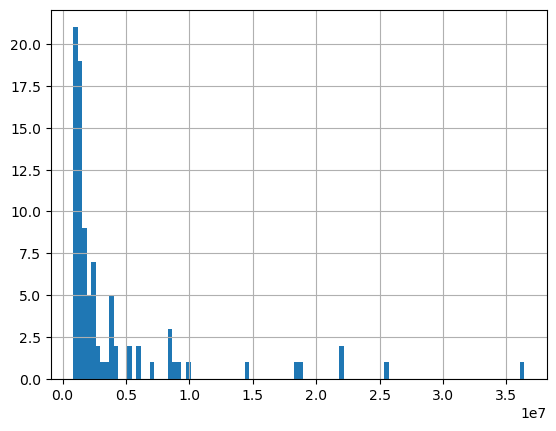

In [77]:
top_quartile_russ['revPerEmp'].hist(bins = 100)

<Axes: >

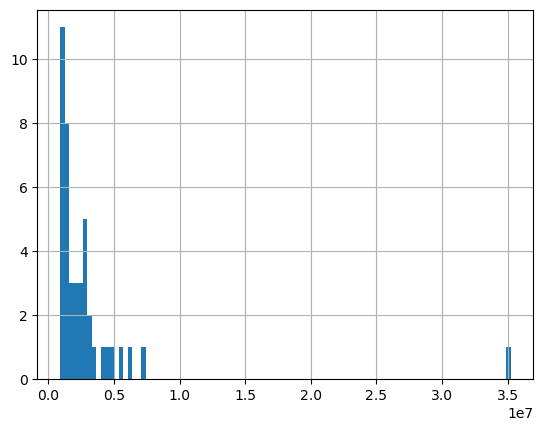

In [78]:
top_quartile_sp500['revPerEmp'].hist(bins = 100)

In [79]:
liquid_sp500 = top_quartile_sp500[top_quartile_sp500['quickRatio'] >= 1]
liquid_russ = top_quartile_russ[top_quartile_russ['quickRatio'] >= 1]

In [80]:
picks = liquid_sp500.merge(liquid_russ, how = 'outer')

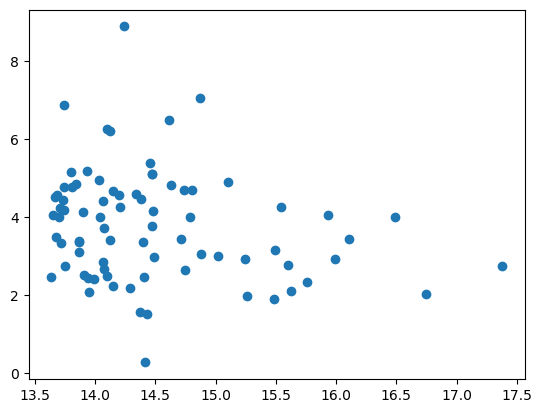

In [81]:
import numpy as np
plt.scatter(x = np.log(picks['revPerEmp']), y = np.log(picks['currentPrice']))

In [85]:
picks = picks[picks['operatingCashflow'] > 0]
picks.head()

,country,industry,sector,overallRisk,dividendRate,dividendYield,beta,trailingPE,marketCap,profitMargins,...,earningsGrowth,symbol,averageAnalystRating,displayName,prevName,nameChangeDate,revPerEmp,trailingAnnualDividendRate,totalCash,totalCashPerShare
0,United States,Semiconductors,Technology,5.0,NaN,NaN,1.968,85.394160,1.896876e+11,0.08025,...,5.252,AMD,1.9 - Buy,Advanced Micro Devices,NaN,NaN,9.910715e+05,NaN,NaN,NaN
1,United States,REIT - Office,Real Estate,7.0,5.28,7.29,1.289,93.263150,1.226146e+10,0.04610,...,NaN,ARE,2.5 - Buy,Alexandria Real Estate Equities,NaN,NaN,5.637393e+06,NaN,NaN,NaN
2,United States,Internet Content & Information,Communication Services,10.0,0.84,0.53,1.010,18.441471,2.015031e+12,0.30857,...,0.488,GOOGL,1.6 - Buy,NaN,NaN,NaN,1.936867e+06,NaN,NaN,NaN
3,United States,Internet Content & Information,Communication Services,NaN,0.84,0.52,1.010,18.607143,2.013694e+12,0.30857,...,0.488,GOOG,1.6 - Buy,Alphabet,NaN,NaN,1.936867e+06,NaN,NaN,NaN
4,United States,Asset Management,Financial Services,6.0,6.40,1.23,1.270,17.769806,4.976434e+10,0.16558,...,-0.384,AMP,2.2 - Buy,Ameriprise Financial,NaN,NaN,1.329559e+06,NaN,NaN,NaN


In [52]:
drop_cols_3 = ['country', 'dividendYield','earningsGrowth', 'averageAnalystRating', 'trailingAnnualDividendRate', 'totalCash','totalCashPerShare']

In [53]:
picks.drop(drop_cols_3, axis= 1, inplace=True)

In [54]:
picks_q2 = picks['bookValue'].quantile(0.5)

# Filter rows where 'Score' is in the top quartile
picks_bv5 = picks[picks['bookValue'] >= picks_q2]


In [55]:
picks_sectors = picks_bv5['sector'].unique()
for x in picks_sectors:
    print(x)
    print(picks_bv5[ picks_bv5['sector'] == x ].to_string())

Technology
                               industry      sector  overallRisk  dividendRate   beta  trailingPE     marketCap  profitMargins  bookValue  currentPrice        ebitda     totalDebt  quickRatio  currentRatio  totalRevenue  debtToEquity  revenuePerShare  returnOnAssets  returnOnEquity  grossProfits  freeCashflow  operatingCashflow symbol             displayName prevName nameChangeDate     revPerEmp
0                        Semiconductors  Technology          5.0           NaN  1.968    85.39416  1.896876e+11        0.08025     35.817       116.990  5.878000e+09  4.731000e+09       1.765         2.803  2.775000e+10         8.174           17.122         0.02560         0.03904  1.486800e+10  3.355625e+09       3.459000e+09    AMD  Advanced Micro Devices      NaN            NaN  9.910715e+05
26      Information Technology Services  Technology          1.0           NaN  1.082         NaN  2.414913e+09        0.03931     40.850        55.135  3.718000e+08  1.352000e+09       2.187

In [56]:
picks_bv5.to_csv('top_picks.csv')

In [57]:
picks = pd.read_csv('top_picks.csv')
picks.head()

,Unnamed: 0,industry,sector,overallRisk,dividendRate,beta,trailingPE,marketCap,profitMargins,bookValue,...,returnOnAssets,returnOnEquity,grossProfits,freeCashflow,operatingCashflow,symbol,displayName,prevName,nameChangeDate,revPerEmp
0,0,Semiconductors,Technology,5.0,NaN,1.968,85.394160,1.896876e+11,0.08025,35.817,...,0.02560,0.03904,1.486800e+10,3.355625e+09,3.459000e+09,AMD,Advanced Micro Devices,NaN,NaN,9.910715e+05
1,1,REIT - Office,Real Estate,7.0,5.28,1.289,93.263150,1.226146e+10,0.04610,102.655,...,0.01304,0.01476,2.194495e+09,1.259090e+09,1.371316e+09,ARE,Alexandria Real Estate Equities,NaN,NaN,5.637393e+06
2,2,Internet Content & Information,Communication Services,10.0,0.84,1.010,18.441471,2.015031e+12,0.30857,28.405,...,0.16897,0.34789,2.107580e+11,6.067900e+10,1.326010e+11,GOOGL,NaN,NaN,NaN,1.936867e+06
3,3,Internet Content & Information,Communication Services,NaN,0.84,1.010,18.607143,2.013694e+12,0.30857,28.405,...,0.16897,0.34789,2.107580e+11,6.067900e+10,1.326010e+11,GOOG,Alphabet,NaN,NaN,1.936867e+06
4,4,Asset Management,Financial Services,6.0,6.40,1.270,17.769806,4.976434e+10,0.16558,56.795,...,0.02222,0.58108,1.023800e+10,3.326500e+09,6.837000e+09,AMP,Ameriprise Financial,NaN,NaN,1.329559e+06


In [58]:
pe_picks = picks[picks['trailingPE']>0]

In [59]:
pe_picks_sectors = pe_picks['sector'].unique()
for x in pe_picks_sectors:
    print(x)
    print(pe_picks[ pe_picks['sector'] == x ].to_string())

Technology
   Unnamed: 0        industry      sector  overallRisk  dividendRate   beta  trailingPE     marketCap  profitMargins  bookValue  currentPrice        ebitda     totalDebt  quickRatio  currentRatio  totalRevenue  debtToEquity  revenuePerShare  returnOnAssets  returnOnEquity  grossProfits  freeCashflow  operatingCashflow symbol             displayName prevName nameChangeDate      revPerEmp
0           0  Semiconductors  Technology          5.0           NaN  1.968    85.39416  1.896876e+11        0.08025     35.817        116.99  5.878000e+09  4.731000e+09       1.765         2.803  2.775000e+10         8.174           17.122          0.0256         0.03904  1.486800e+10  3.355625e+09       3.459000e+09    AMD  Advanced Micro Devices      NaN            NaN  991071.451429
Real Estate
   Unnamed: 0       industry       sector  overallRisk  dividendRate   beta  trailingPE     marketCap  profitMargins  bookValue  currentPrice        ebitda     totalDebt  quickRatio  currentRatio  

In [88]:
pe_picks.to_excel('website/pe_picks.xlsx', index=False)

In [ ]:
#python -m http.server 8000 to run the site